# Computational essay draft

## Denmark: did more wind power show up as cleaner electricity?

I wanted this essay to feel like a realistic first computational essay, not a huge research project. I chose one country, one time period, one public dataset and one main figure. The goal is to make a clear argument with numbers, while also being honest about what the data cannot prove.


## Focused question

Between 2010 and 2024, how did Denmark's wind share of electricity generation and electricity carbon intensity change?

I chose Denmark because the change is large enough to see in a short notebook. At the same time, the answer is not automatic. More wind should help, but the carbon intensity of a grid also depends on demand, imports, fossil generation, policy and other renewable sources.


## System boundary and quantities

**System:** Denmark's national electricity system.

**Period:** annual data from 2010 to 2024.

**Main quantities:**

- wind share of electricity generation, in percent;
- solar share of electricity generation, in percent;
- renewable share of electricity generation, in percent;
- electricity carbon intensity, in gCO2/kWh;
- electricity demand, in TWh.

My boundary is intentionally narrow: national annual averages only. I do not model hourly balancing, imports or exports. That makes the essay manageable, but it also means the conclusion has to be careful.


## Data source

This notebook reads the local course files so the calculation is stable and reproducible:

- `data/FYS10XX_energy_data_2010_2024.csv`
- `data/FYS10XX_energy_data_dictionary.csv`

The actual source chain is:

- **Topic and citation page:** [Our World in Data - Energy](https://ourworldindata.org/energy)
- **Complete dataset repository:** [owid/energy-data on GitHub](https://github.com/owid/energy-data)
- **Original full CSV download:** [OWID Energy CSV](https://owid-public.owid.io/data/energy/owid-energy-data.csv)
- **Original codebook:** [OWID Energy codebook CSV](https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-codebook.csv)
- **Main underlying source for the electricity variables used here:** [Ember Yearly Electricity Data](https://ember-energy.org/data/yearly-electricity-data/)

The local course CSV is a selected teaching subset: eight countries, years 2010-2024, and documented electricity variables. According to the course data README, the values were selected and reordered but not numerically changed.

I use the column dictionary before trusting the column names, because `wind_share_elec` and `carbon_intensity_elec` are not self-explanatory unless their units are known. The important source habit here is to cite the original data provider and the underlying source, not only the local CSV file.

Source: Our World in Data Energy Data (https://ourworldindata.org/energy), with the electricity variables used here based mainly on Ember Yearly Electricity Data (https://ember-energy.org/data/yearly-electricity-data/); course subset accessed 21 June 2026.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data/FYS10XX_energy_data_2010_2024.csv")
dictionary = pd.read_csv("data/FYS10XX_energy_data_dictionary.csv")

columns_to_check = [
    "wind_share_elec",
    "solar_share_elec",
    "renewables_share_elec",
    "carbon_intensity_elec",
    "electricity_demand",
]

dictionary[
    dictionary["column"].isin(columns_to_check)
][["column", "description", "unit", "course_note"]]


The dictionary confirms percent, gCO2/kWh and TWh units for the selected variables.


In [2]:
denmark = data[
    (data["country"] == "Denmark")
    & (data["year"].between(2010, 2024))
].copy()

denmark = denmark[
    [
        "year",
        "wind_share_elec",
        "solar_share_elec",
        "renewables_share_elec",
        "carbon_intensity_elec",
        "electricity_demand",
    ]
].reset_index(drop=True)

denmark


Filtered table: Denmark, 2010-2024, 15 annual rows.


## First look at the data

| year | wind share (%) | solar share (%) | renewables share (%) | carbon intensity (gCO2/kWh) | electricity demand (TWh) |
|---|---:|---:|---:|---:|---:|
| 2010 | 20.2 | 0.0 | 32.1 | 540.4 | 37.6 |
| 2015 | 49.1 | 2.1 | 65.8 | 313.8 | 34.7 |
| 2020 | 57.1 | 4.1 | 82.1 | 188.9 | 35.5 |
| 2024 | 58.2 | 10.8 | 89.2 | 131.8 | 38.8 |

This table is my first check before plotting anything. It already suggests the main story: wind grows strongly, solar also appears, and the carbon intensity falls.


In [3]:
first = denmark.iloc[0]
last = denmark.iloc[-1]

wind_change = last["wind_share_elec"] - first["wind_share_elec"]
intensity_change = last["carbon_intensity_elec"] - first["carbon_intensity_elec"]
demand_change = last["electricity_demand"] - first["electricity_demand"]

# A rough operational emissions estimate.
# TWh x gCO2/kWh / 1000 = MtCO2
co2_2010_Mt = first["electricity_demand"] * first["carbon_intensity_elec"] / 1000
co2_2024_Mt = last["electricity_demand"] * last["carbon_intensity_elec"] / 1000
co2_drop_percent = (co2_2010_Mt - co2_2024_Mt) / co2_2010_Mt * 100

print(f"Wind share: {first['wind_share_elec']:.1f}% -> {last['wind_share_elec']:.1f}%")
print(f"Change in wind share: {wind_change:.1f} percentage points")
print(f"Carbon intensity: {first['carbon_intensity_elec']:.1f} -> {last['carbon_intensity_elec']:.1f} gCO2/kWh")
print(f"Change in carbon intensity: {intensity_change:.1f} gCO2/kWh")
print(f"Electricity demand: {first['electricity_demand']:.1f} -> {last['electricity_demand']:.1f} TWh")
print(f"Estimated operational CO2: {co2_2010_Mt:.1f} -> {co2_2024_Mt:.1f} MtCO2")
print(f"Estimated drop: {co2_drop_percent:.0f}%")


Wind share: 20.2% -> 58.2% (change 38.1 percentage points)
Carbon intensity: 540.4 -> 131.8 gCO2/kWh (change -408.6 gCO2/kWh)
Electricity demand: 37.6 -> 38.8 TWh (change 1.2 TWh)
Estimated operational electricity CO2: 20.3 -> 5.1 MtCO2 (drop 75%)


## Figure

The two quantities use different units, so I put them in two panels instead of forcing both lines onto one axis. That makes the graph a bit less flashy, but easier to read.


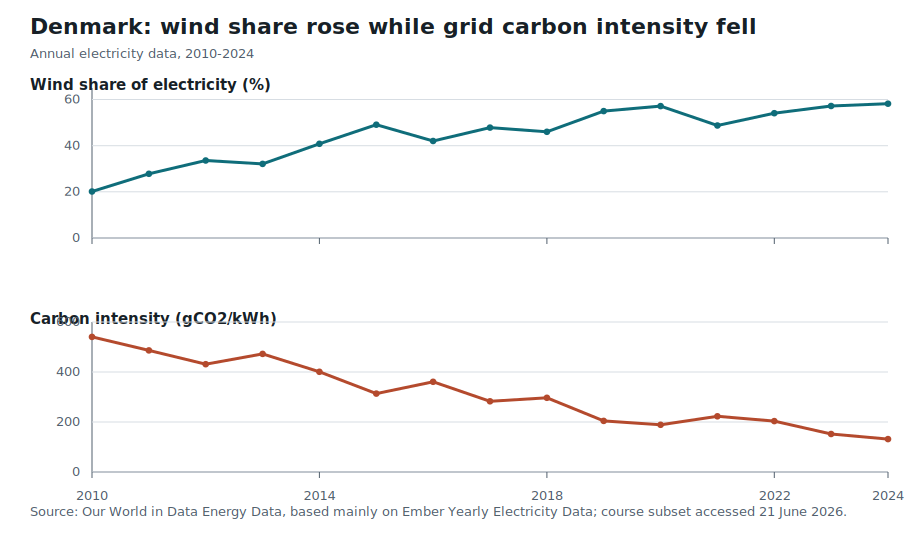

Source: Our World in Data Energy Data (https://ourworldindata.org/energy), with the electricity variables used here based mainly on Ember Yearly Electricity Data (https://ember-energy.org/data/yearly-electricity-data/); course subset accessed 21 June 2026.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axes[0].plot(denmark["year"], denmark["wind_share_elec"], marker="o")
axes[0].set_ylabel("Wind share (%)")
axes[0].set_title("Denmark: wind share of electricity generation")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    denmark["year"],
    denmark["carbon_intensity_elec"],
    marker="o",
    color="tab:red",
)
axes[1].set_ylabel("Carbon intensity (gCO2/kWh)")
axes[1].set_xlabel("Year")
axes[1].set_title("Denmark: electricity carbon intensity")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "Source: Our World in Data Energy Data, based mainly on Ember Yearly "
    "Electricity Data; course subset accessed 21 June 2026."
)


## Interpretation

The result is quite clear. Denmark's wind share rose from **20.2%** in 2010 to **58.2%** in 2024, an increase of **38.1 percentage points**.

Over the same period, the electricity carbon intensity fell from **540.4 gCO2/kWh** to **131.8 gCO2/kWh**, a decrease of **408.6 gCO2/kWh**.

Electricity demand stayed almost flat in this dataset, moving from **37.6 TWh** to **38.8 TWh**. That matters because the carbon-intensity change is not being hidden by a huge demand increase.


## A small extra calculation

Using annual demand and carbon intensity as a rough operational estimate:

`CO2 = electricity demand x carbon intensity / 1000`

For 2010:

`37.6 TWh x 540.4 gCO2/kWh / 1000 = 20.3 MtCO2`

For 2024:

`38.8 TWh x 131.8 gCO2/kWh / 1000 = 5.1 MtCO2`

This simple estimate falls by about **75%**. I would not over-sell this as an exact emissions inventory, but it is a useful scale check.


## Limitations

This result is evidence of a strong change in Denmark's electricity mix, but it is not proof that wind power alone caused the lower carbon intensity.

The model leaves out:

- hourly variation in wind and demand;
- imports and exports of electricity;
- fossil fuel price changes and policy changes;
- changes in other renewable sources;
- curtailment, storage and transmission constraints;
- life-cycle emissions from building energy infrastructure.

These limits are not just weaknesses. They are the boundary of this small essay, and they explain why my conclusion has to be careful.


## Conclusion

For Denmark in the course dataset, wind power became a much larger part of electricity generation between 2010 and 2024, while electricity carbon intensity fell sharply. My main claim is that Denmark's electricity system became much cleaner over this period, and the data supports that claim.

The careful version of the claim is:

> Denmark's rising wind share appears together with a large decrease in electricity carbon intensity, but the dataset alone does not isolate wind as the only cause.

This is the kind of claim I think fits a computational essay: it uses a numerical result, gives a physical interpretation, and draws a clear line around what the calculation can and cannot say.


## Comparison with strong computational essays

I compared this draft with stronger computational essays used in university physics courses. Mine is much smaller, but it follows the same basic logic.

| Feature | Strong university examples | This FYS10XX example |
|---|---|---|
| Main question | Starts from a focused, answerable question | Asks whether Denmark's wind growth appears together with cleaner electricity |
| Role of code | Code output drives the argument | The table, calculation and figure support the claim |
| Physics/model | Often includes a simulation or derived model | Uses energy-data accounting and a simple emissions estimate |
| Assumptions | States simplifying assumptions before interpreting results | States national annual boundary and leaves out hourly balancing/imports |
| Conclusion | Gives a claim plus limits | Says the grid became cleaner, but does not claim wind was the only cause |

The [University of Oslo Computational Essay Showroom](https://uio-ccse.github.io/computational-essay-showroom/) is a good reference because it shows computational essays as real pieces of writing where code supports a thesis. Its example essays, such as the [railgun-to-ISS essay](https://uio-ccse.github.io/computational-essay-showroom/essays/exampleessays/railgun_TOO/Railgun_V1_9.html), are more open-ended and simulation-heavy than this course draft.

This FYS10XX version is intentionally more modest. It uses one documented public dataset, one country, one time period and one main figure. That makes it realistic for a 5-credit introductory course while still copying the good university-course habits: question, boundary, method, code, evidence, interpretation and limitations.

Two useful background readings on the method are [Computational Essays in the Physics Classroom](https://arxiv.org/abs/1907.04896) and [Using Computational Essays to Scaffold Professional Physics Practice](https://arxiv.org/abs/2006.10565). The practical lesson from both is that the notebook should read like an argument, not like loose code cells.


## What I would improve next

If I had more time, I would change one thing at a time instead of making the project bigger in every direction:

- compare Denmark with Germany or Kenya;
- use solar share instead of wind share;
- examine carbon intensity and electricity demand together;
- focus on one period, such as 2015-2024;
